In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
quants = pd.read_csv("eval-all/quants_all.csv", index_col=0)
quants["question_type"] = quants["question_type"].str.rsplit("_", n=1).str[0]
quants

,question_id,question,answer,answer_text,question_type,answer_type
sample_id,,,,,,
0,0,How often does the person undertake running?,NaN,1,count,open
0,1,What action was undertaken by the person direc...,1.0,The correct answer is holding a baby.,right_after,multi
0,2,What is the number of times the individual has...,NaN,1,count,open
0,3,Is the action at 8.174 the same as the action ...,0.0,No,comparison_timestamp_same,binary
0,4,Did the person perform exactly 2 different act...,0.0,False,interval_part_sequence,binary
...,...,...,...,...,...,...
29999,0,"In terms of occurrence, was the person's invol...",1.0,True,extremum_least,binary
29999,1,Are the initial and final actions identical to...,0.0,No,comparison_first_last_same,binary
29999,2,Some time before the person performed playing ...,0.0,The correct answer is picking something up wit...,before,multi


In [9]:
df = pd.concat(
    {
        "TS Evol-Instruct": pd.read_csv(
            "eval-all/chatts_sft_evol_instruct_train.csv", index_col=0
        ),
        "(Tune-)OpenSQA": pd.read_csv(
            "eval-all/llasa_open_sqa_v2_and_tune.csv", index_col=0
        ),
        "QuAnTS": quants,
    },
).droplevel(1, axis="index")[["question_type", "answer_type"]]
df

,question_type,answer_type
TS Evol-Instruct,other,binary
TS Evol-Instruct,descriptive_identification,open
TS Evol-Instruct,other,open
TS Evol-Instruct,descriptive_identification,multi
TS Evol-Instruct,descriptive_identification,multi
...,...,...
QuAnTS,extremum_least,binary
QuAnTS,comparison_first_last_same,binary
QuAnTS,before,multi
QuAnTS,extremum_most,binary


In [10]:
df["question_type"].value_counts(normalize=True, dropna=False) * 100

question_type
other                              51.034809
NaN                                 5.604440
descriptive_identification          5.043863
count                               3.348317
last                                3.000282
first                               2.967869
right_before                        2.582639
right_after                         2.581045
after                               2.552352
before                              2.516220
extremum_most                       2.467335
interval_part_sequence              2.462022
interval_whole_sequence             2.386038
comparison_counting                 2.203519
count_number                        1.961488
extremum_least                      1.637628
comparison                          1.591666
comparison_timestamp_different      1.050218
comparison_first_last_same          1.015946
comparison_first_last_different     1.002928
comparison_timestamp_same           0.989378
Name: proportion, dtype: float64

In [11]:
df

,question_type,answer_type
TS Evol-Instruct,other,binary
TS Evol-Instruct,descriptive_identification,open
TS Evol-Instruct,other,open
TS Evol-Instruct,descriptive_identification,multi
TS Evol-Instruct,descriptive_identification,multi
...,...,...
QuAnTS,extremum_least,binary
QuAnTS,comparison_first_last_same,binary
QuAnTS,before,multi
QuAnTS,extremum_most,binary


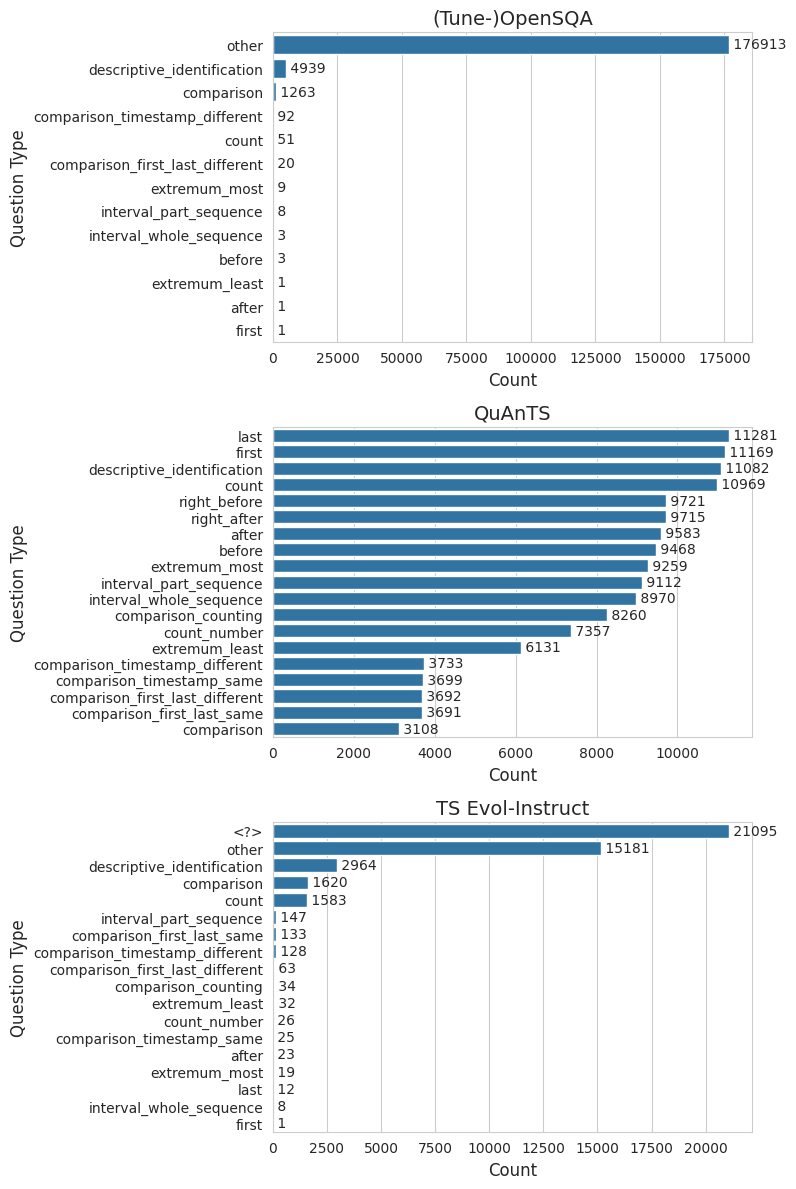

In [12]:
# --- 3. Plotting ---
# Set the visual style of the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots. The size and number of plots are adjusted automatically.
num_datasets = df.index.nunique()
fig, axes = plt.subplots(num_datasets, 1, figsize=(8, 4 * num_datasets), squeeze=False)
axes = axes.squeeze(-1)

# Loop through the datasets and create a plot for each
for i, (title, df_sub) in enumerate(df.groupby(level=0)):
    # Calculate the frequency of each class/category
    class_counts = df_sub["question_type"].fillna("<?>").value_counts()

    # Create the horizontal bar plot on the appropriate subplot
    sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[i], orient="h")

    # Customize the plot with a title and labels
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel("Count", fontsize=12)
    axes[i].set_ylabel("Question Type", fontsize=12)

    # Add the exact count as a text label on each bar for clarity
    for index, value in enumerate(class_counts):
        axes[i].text(value, index, f" {value}", va="center", fontsize=10)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout()